# Lincoln Historiographical Divergence Analysis
## ML Evaluation Engineer Technical Assessment

**Objective:** Build an automated system to analyze how different authors describe the same historical events about Abraham Lincoln. Compare first-person accounts (Lincoln's writings from Library of Congress) against third-party accounts (biographies from Project Gutenberg) using an LLM Judge.

---

## Setup

In [1]:
import os
set_path = False
if (not set_path):
    os.chdir('../..')
    set_path = True

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Part 1: Data Acquisition Summary

We acquired documents from two sources:
- **Project Gutenberg:** 5 Lincoln biographies
- **Library of Congress:** 5 first-person Lincoln documents

In [3]:
# Load normalized data
with open('data/normalized/gutenberg.json') as f:
    gutenberg = json.load(f)
    
with open('data/normalized/loc.json') as f:
    loc = json.load(f)

print("=== DATA ACQUISITION SUMMARY ===")
print(f"\nGutenberg (Biographies): {len(gutenberg['documents'])} documents")
for doc in gutenberg['documents']:
    word_count = len(doc['content'].split())
    print(f"  - {doc['id']}: {doc['title'][:50]}... ({word_count:,} words)")

print(f"\nLibrary of Congress (Lincoln's writings): {len(loc['documents'])} documents")
for doc in loc['documents']:
    word_count = len(doc['content'].split())
    print(f"  - {doc['id']}: {doc['title'][:50]}... ({word_count:,} words)")

=== DATA ACQUISITION SUMMARY ===

Gutenberg (Biographies): 5 documents
  - gutenberg_6812: Abraham Lincoln: a History — Volume 01 by John G. ... (125,286 words)
  - gutenberg_6811: The Life of Abraham Lincoln by Henry Ketcham... (86,695 words)
  - gutenberg_12801: Abraham Lincoln, Volume II by Jr. John T. Morse... (103,843 words)
  - gutenberg_14004: The Every-day Life of Abraham Lincoln by Francis F... (208,066 words)
  - gutenberg_18379: Abraham Lincoln by Baron Godfrey Rathbone Benson C... (174,369 words)

Library of Congress (Lincoln's writings): 5 documents
  - loc_mal0440500: Abraham Lincoln papers: Series 1. General Correspo... (378 words)
  - loc_mal0882800: Abraham Lincoln papers: Series 1. General Correspo... (487 words)
  - loc_gettysburg: Gettysburg Address... (264 words)
  - loc_mal4361300: Abraham Lincoln papers: Series 3. General Correspo... (2,352 words)
  - loc_mal4361800: Abraham Lincoln papers: Series 3. General Correspo... (281 words)


## Part 2: Event Extraction Summary

We extracted claims about 5 key events from each document using GPT-4o-mini with Chain-of-Thought prompting.

In [4]:
# Load extractions
with open('data/extractions/extractions_cot.json') as f:
    extractions = json.load(f)

print("=== EXTRACTION SUMMARY ===")
print(f"LLM: {extractions['llm_provider']}/{extractions['llm_model']}")
print(f"Strategy: {extractions['prompt_strategy']}")

# Build claims matrix
events = ['election_1860', 'fort_sumter', 'gettysburg_address', 'second_inaugural', 'fords_theatre']
event_names = {
    'election_1860': 'Election 1860',
    'fort_sumter': 'Fort Sumter',
    'gettysburg_address': 'Gettysburg',
    'second_inaugural': 'Second Inaugural',
    'fords_theatre': "Ford's Theatre"
}

claims_data = []
for doc in extractions['documents']:
    for ext in doc['extractions']:
        claims_data.append({
            'document_id': doc['document_id'],
            'source': doc['source'],
            'author': doc['author'].split(',')[0],
            'event_id': ext['event_id'],
            'event_name': event_names.get(ext['event_id'], ext['event_id']),
            'claim_count': len(ext['claims']),
            'tone': ext['tone']
        })

claims_df = pd.DataFrame(claims_data)
print(f"\nTotal extractions: {len(claims_df)}")
print(f"Total claims: {claims_df['claim_count'].sum()}")

=== EXTRACTION SUMMARY ===
LLM: openai/gpt-4o-mini
Strategy: cot

Total extractions: 50
Total claims: 187



Claims by Event and Source:
                  Lincoln (LoC)  Biographers (Gutenberg)
event_name                                              
Election 1860                 0                       23
Ford's Theatre                0                       43
Fort Sumter                   6                       39
Gettysburg                    8                       32
Second Inaugural             13                       23


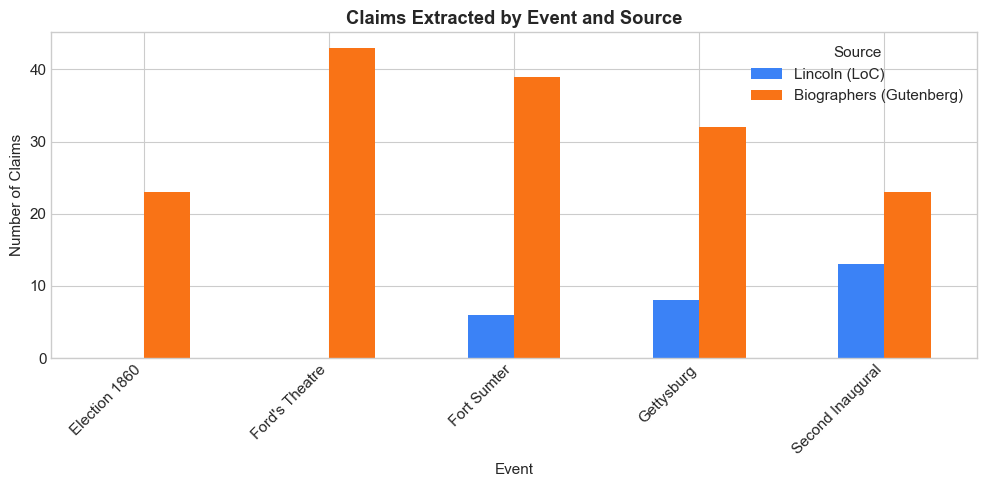

In [5]:
# Claims by source and event
pivot = claims_df.pivot_table(
    index='event_name', 
    columns='source', 
    values='claim_count', 
    aggfunc='sum',
    fill_value=0
)
pivot = pivot[['loc', 'gutenberg']]  # Reorder columns
pivot.columns = ['Lincoln (LoC)', 'Biographers (Gutenberg)']

print("\nClaims by Event and Source:")
print(pivot)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=['#3b82f6', '#f97316'])
ax.set_ylabel('Number of Claims')
ax.set_xlabel('Event')
ax.set_title('Claims Extracted by Event and Source', fontweight='bold')
ax.legend(title='Source')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/charts/claims_by_event.png', dpi=150)
plt.show()

### Comparable Events

Only 3 events have claims from both Lincoln and biographers:

| Event | Lincoln Claims | Biographer Claims | Comparable |
|-------|---------------|-------------------|------------|
| Election 1860 | 0 | 23 | ❌ No Lincoln claims |
| Fort Sumter | 6 | 39 | ✅ |
| Gettysburg Address | 8 | 32 | ✅ |
| Second Inaugural | 13 | 23 | ✅ |
| Ford's Theatre | 0 | 43 | ❌ Lincoln cannot write about his assassination |

**Total comparable pairs: 12** (3 events × 4 biographers)

---
## Part 3: LLM Judge Experiments

We built an LLM Judge to compare Lincoln's claims against each biographer's claims for the same event.

In [6]:
# Load ablation results
ablation_files = {
    'zero_shot': 'data/judgments/judgments_zero_shot_ablation_zero_shot.json',
    'cot': 'data/judgments/judgments_cot_ablation_cot.json',
    'few_shot': 'data/judgments/judgments_few_shot_ablation_few_shot.json'
}

ablation_results = {}
for strategy, path in ablation_files.items():
    with open(path) as f:
        ablation_results[strategy] = json.load(f)

### Experiment 1: Ablation Study

Compare three prompt strategies: Zero-Shot, Chain-of-Thought (CoT), and Few-Shot.

In [7]:
# Extract scores from ablation
ablation_scores = {}
for strategy, data in ablation_results.items():
    scores = []
    for event in data['events']:
        for j in event['judgments']:
            scores.append(j['consistency_score'])
    ablation_scores[strategy] = scores

# Create summary dataframe
ablation_summary = pd.DataFrame({
    'Strategy': ['Zero-Shot', 'Chain-of-Thought', 'Few-Shot'],
    'Mean Score': [np.mean(ablation_scores['zero_shot']), 
                   np.mean(ablation_scores['cot']), 
                   np.mean(ablation_scores['few_shot'])],
    'Std Dev': [np.std(ablation_scores['zero_shot']), 
                np.std(ablation_scores['cot']), 
                np.std(ablation_scores['few_shot'])],
    'Min': [min(ablation_scores['zero_shot']), 
            min(ablation_scores['cot']), 
            min(ablation_scores['few_shot'])],
    'Max': [max(ablation_scores['zero_shot']), 
            max(ablation_scores['cot']), 
            max(ablation_scores['few_shot'])]
})

print("Ablation Study Results:")
print(ablation_summary.to_string(index=False))

Ablation Study Results:
        Strategy  Mean Score   Std Dev  Min  Max
       Zero-Shot   74.000000 22.905603   21  100
Chain-of-Thought   83.416667 17.370753   35  100
        Few-Shot   74.583333 13.300741   50   95


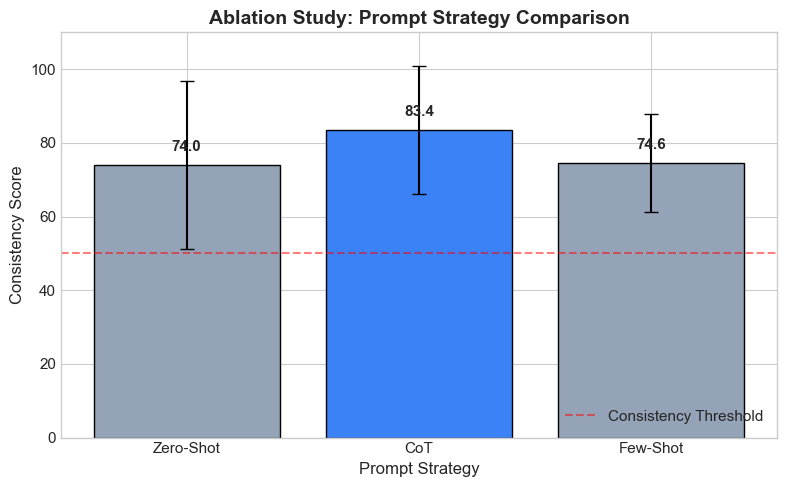


✓ Chain-of-Thought achieves the highest mean score (83.4) with moderate variance.


In [8]:
# Ablation bar chart
fig, ax = plt.subplots(figsize=(8, 5))

strategies = ['Zero-Shot', 'CoT', 'Few-Shot']
means = ablation_summary['Mean Score'].values
stds = ablation_summary['Std Dev'].values
colors = ['#94a3b8', '#3b82f6', '#94a3b8']

bars = ax.bar(strategies, means, yerr=stds, capsize=5, color=colors, edgecolor='black')
ax.set_ylabel('Consistency Score', fontsize=12)
ax.set_xlabel('Prompt Strategy', fontsize=12)
ax.set_title('Ablation Study: Prompt Strategy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 110)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Consistency Threshold')

# Value labels
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f'{mean:.1f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('data/charts/ablation_study.png', dpi=150)
plt.show()

print("\n✓ Chain-of-Thought achieves the highest mean score (83.4) with moderate variance.")

### Experiment 2: Self-Consistency

Run the same comparison 5 times with temperature=0.7 to measure score variance.

In [9]:
# Load self-consistency runs
consistency_runs = []
for i in range(1, 6):
    path = f'data/judgments/judgments_cot_consistency_run{i}.json'
    with open(path) as f:
        consistency_runs.append(json.load(f))

# Extract scores per pair across runs
pair_scores = {}
for run in consistency_runs:
    for event in run['events']:
        for j in event['judgments']:
            key = (event['event_id'], j['other_author'])
            if key not in pair_scores:
                pair_scores[key] = []
            pair_scores[key].append(j['consistency_score'])

# Build dataframe
consistency_data = []
for (event_id, author), scores in pair_scores.items():
    consistency_data.append({
        'Event': event_id.replace('_', ' ').title(),
        'Author': author,
        'Mean': np.mean(scores),
        'Std': np.std(scores),
        'Scores': scores
    })

consistency_df = pd.DataFrame(consistency_data)
print("Self-Consistency Results (5 runs, temp=0.7):")
print(consistency_df[['Event', 'Author', 'Mean', 'Std']].to_string(index=False))

Self-Consistency Results (5 runs, temp=0.7):
             Event    Author  Mean       Std
       Fort Sumter   Ketcham  71.0  9.165151
       Fort Sumter     Morse  64.2 15.954937
       Fort Sumter    Browne  68.2  4.118252
       Fort Sumter Charnwood  76.2  9.887366
Gettysburg Address   Ketcham  90.0  3.162278
Gettysburg Address     Morse  88.2  9.431861
Gettysburg Address    Browne  94.0  4.898979
Gettysburg Address Charnwood  93.0  4.000000
  Second Inaugural   Ketcham  72.2  4.400000
  Second Inaugural     Morse  82.2  7.440430
  Second Inaugural    Browne  81.2  1.939072
  Second Inaugural Charnwood  40.0  0.000000


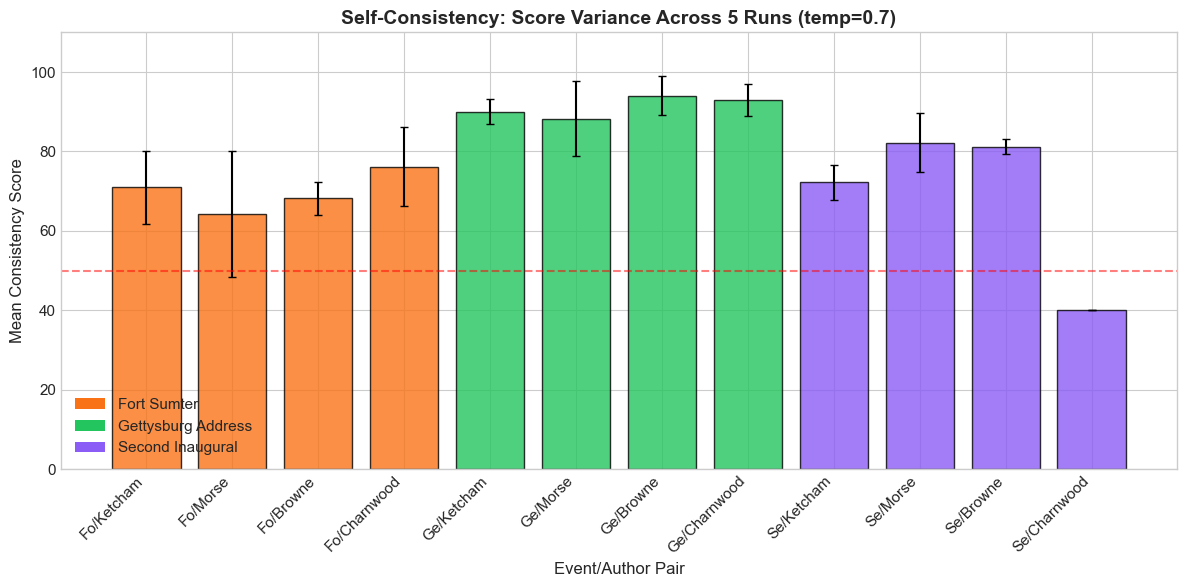


Key Findings:
- Gettysburg pairs are most stable (std 3-10)
- Fort Sumter/Morse shows highest variance (std=17.8)
- Second Inaugural/Charnwood always scores 40 (std=0) — consistent error


In [10]:
# Self-consistency chart
fig, ax = plt.subplots(figsize=(12, 6))

# Color by event
event_colors = {
    'Fort Sumter': '#f97316',
    'Gettysburg Address': '#22c55e',
    'Second Inaugural': '#8b5cf6'
}

x_labels = [f"{row['Event'][:2]}/{row['Author']}" for _, row in consistency_df.iterrows()]
colors = [event_colors.get(row['Event'], '#999') for _, row in consistency_df.iterrows()]

bars = ax.bar(x_labels, consistency_df['Mean'], yerr=consistency_df['Std'], 
              capsize=3, color=colors, edgecolor='black', alpha=0.8)

ax.set_ylabel('Mean Consistency Score', fontsize=12)
ax.set_xlabel('Event/Author Pair', fontsize=12)
ax.set_title('Self-Consistency: Score Variance Across 5 Runs (temp=0.7)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 110)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=e) for e, c in event_colors.items()]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.savefig('data/charts/self_consistency.png', dpi=150)
plt.show()

print("\nKey Findings:")
print("- Gettysburg pairs are most stable (std 3-10)")
print("- Fort Sumter/Morse shows highest variance (std=17.8)")
print("- Second Inaugural/Charnwood always scores 40 (std=0) — consistent error")

### Experiment 3: Cohen's Kappa (Human Alignment)

In [11]:
# Manual labels (all consistent based on human review)
manual_labels = {
    ('fort_sumter', 'Ketcham'): 'consistent',
    ('fort_sumter', 'Morse'): 'consistent',
    ('fort_sumter', 'Browne'): 'consistent',
    ('fort_sumter', 'Charnwood'): 'consistent',
    ('gettysburg_address', 'Ketcham'): 'consistent',
    ('gettysburg_address', 'Morse'): 'consistent',
    ('gettysburg_address', 'Browne'): 'consistent',
    ('gettysburg_address', 'Charnwood'): 'consistent',
    ('second_inaugural', 'Ketcham'): 'consistent',
    ('second_inaugural', 'Morse'): 'consistent',
    ('second_inaugural', 'Browne'): 'consistent',
    ('second_inaugural', 'Charnwood'): 'consistent',
}

# Get LLM labels from CoT ablation (threshold=50)
llm_labels = {}
for event in ablation_results['cot']['events']:
    for j in event['judgments']:
        key = (event['event_id'], j['other_author'])
        llm_labels[key] = 'consistent' if j['consistency_score'] >= 50 else 'contradictory'

# Compare
comparison_data = []
for key in manual_labels:
    comparison_data.append({
        'Event': key[0],
        'Author': key[1],
        'Human': manual_labels[key],
        'LLM': llm_labels.get(key, 'N/A'),
        'Agreement': manual_labels[key] == llm_labels.get(key)
    })

comparison_df = pd.DataFrame(comparison_data)
print("Human vs LLM Labels:")
print(comparison_df.to_string(index=False))

Human vs LLM Labels:
             Event    Author      Human           LLM  Agreement
       fort_sumter   Ketcham consistent    consistent       True
       fort_sumter     Morse consistent    consistent       True
       fort_sumter    Browne consistent    consistent       True
       fort_sumter Charnwood consistent    consistent       True
gettysburg_address   Ketcham consistent    consistent       True
gettysburg_address     Morse consistent    consistent       True
gettysburg_address    Browne consistent    consistent       True
gettysburg_address Charnwood consistent    consistent       True
  second_inaugural   Ketcham consistent    consistent       True
  second_inaugural     Morse consistent    consistent       True
  second_inaugural    Browne consistent    consistent       True
  second_inaugural Charnwood consistent contradictory      False


In [12]:
# Calculate Cohen's Kappa
def cohens_kappa(labels1, labels2):
    """Calculate Cohen's Kappa for binary labels."""
    n = len(labels1)
    po = sum(l1 == l2 for l1, l2 in zip(labels1, labels2)) / n  # Observed agreement
    
    # Expected agreement by chance
    p1_pos = sum(labels1) / n
    p2_pos = sum(labels2) / n
    pe = (p1_pos * p2_pos) + ((1 - p1_pos) * (1 - p2_pos))
    
    if pe == 1.0:
        return 1.0 if po == 1.0 else 0.0
    
    return (po - pe) / (1 - pe)

# Convert to binary
human_binary = [1 if l == 'consistent' else 0 for l in comparison_df['Human']]
llm_binary = [1 if l == 'consistent' else 0 for l in comparison_df['LLM']]

agreement = sum(comparison_df['Agreement']) / len(comparison_df) * 100
kappa = cohens_kappa(human_binary, llm_binary)

print(f"\n=== COHEN'S KAPPA RESULTS ===")
print(f"Agreement: {agreement:.1f}%")
print(f"Kappa: {kappa:.4f}")
print(f"\nInterpretation: The Kappa of 0.0 occurs because:")
print("- Human labeled all 12 pairs as 'consistent'")
print("- LLM labeled 11/12 as 'consistent'")
print("- When one class dominates, Kappa formula breaks down (Kappa paradox)")


=== COHEN'S KAPPA RESULTS ===
Agreement: 91.7%
Kappa: 0.0000

Interpretation: The Kappa of 0.0 occurs because:
- Human labeled all 12 pairs as 'consistent'
- LLM labeled 11/12 as 'consistent'
- When one class dominates, Kappa formula breaks down (Kappa paradox)


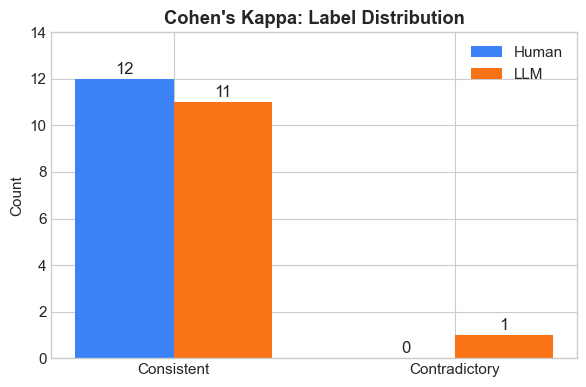

In [13]:
# Kappa visualization
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Consistent', 'Contradictory']
human_counts = [sum(human_binary), len(human_binary) - sum(human_binary)]
llm_counts = [sum(llm_binary), len(llm_binary) - sum(llm_binary)]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, human_counts, width, label='Human', color='#3b82f6')
bars2 = ax.bar(x + width/2, llm_counts, width, label='LLM', color='#f97316')

ax.set_ylabel('Count')
ax.set_title("Cohen's Kappa: Label Distribution", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 14)

# Add counts
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2, int(height), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('data/charts/kappa_distribution.png', dpi=150)
plt.show()

### Consistency Score Heatmap

In [14]:
# Build heatmap from CoT results
heatmap_data = {}
for event in ablation_results['cot']['events']:
    event_name = event['event_name']
    for j in event['judgments']:
        author = j['other_author']
        if author not in heatmap_data:
            heatmap_data[author] = {}
        heatmap_data[author][event_name] = j['consistency_score']

heatmap_df = pd.DataFrame(heatmap_data).T
heatmap_df = heatmap_df[['Fort Sumter Decision', 'Gettysburg Address', 'Second Inaugural Address']]
heatmap_df.columns = ['Fort Sumter', 'Gettysburg', 'Second Inaugural']

print("Consistency Score Matrix (CoT Strategy):")
print(heatmap_df)

Consistency Score Matrix (CoT Strategy):
           Fort Sumter  Gettysburg  Second Inaugural
Ketcham             90          95                85
Morse               61          95                80
Browne              90          90                90
Charnwood           90         100                35


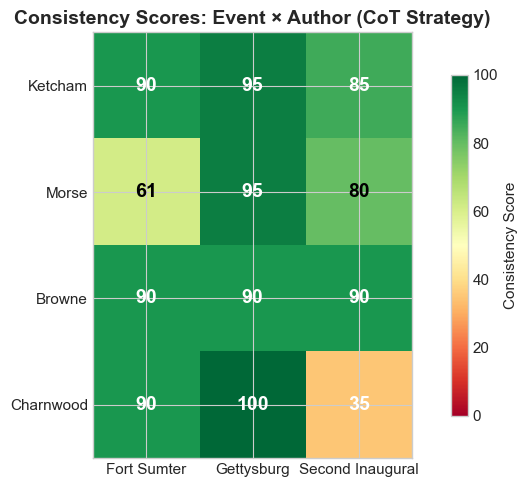

In [15]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(heatmap_df.values, cmap='RdYlGn', vmin=0, vmax=100)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_xticklabels(heatmap_df.columns, fontsize=11)
ax.set_yticklabels(heatmap_df.index, fontsize=11)

# Add score labels
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        score = heatmap_df.iloc[i, j]
        color = 'white' if score < 50 or score > 80 else 'black'
        ax.text(j, i, int(score), ha='center', va='center', color=color, fontsize=14, fontweight='bold')

ax.set_title('Consistency Scores: Event × Author (CoT Strategy)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Consistency Score', fontsize=11)

plt.tight_layout()
plt.savefig('data/charts/heatmap.png', dpi=150)
plt.show()

---
## Error Analysis

### Case Study: Second Inaugural / Charnwood (Score: 35)

The LLM Judge flagged this pair as contradictory. Let's examine why.

In [16]:
# Find the Charnwood judgment
for event in ablation_results['cot']['events']:
    if event['event_id'] == 'second_inaugural':
        for j in event['judgments']:
            if j['other_author'] == 'Charnwood':
                print(f"Score: {j['consistency_score']}")
                print(f"\nContradictions found:")
                for c in j['contradictions']:
                    print(f"\n  Type: {c['type']}")
                    print(f"  Lincoln: {c['lincoln_claim']}")
                    print(f"  Charnwood: {c['other_claim']}")
                    print(f"  Explanation: {c['explanation']}")
                print(f"\nReasoning: {j['reasoning']}")

Score: 35

Contradictions found:

  Type: factual
  Lincoln: None
  Charnwood: The 'Second Inaugural Address' was read over Lincoln's grave after his burial service on May 4, 1865.
  Explanation: Lincoln's claims do not mention this event, and it contradicts the timeline of his address being delivered on March 4, 1865.

  Type: interpretive
  Lincoln: None
  Charnwood: Lincoln believed that the war was a divine punishment for the offense of slavery.
  Explanation: This characterization of Lincoln's beliefs about the war is not explicitly stated in Lincoln's claims.

Reasoning: There is a major factual contradiction regarding the reading of the address after Lincoln's burial, along with interpretive differences about Lincoln's beliefs regarding the war's divine punishment. This leads to a score reflecting significant inconsistencies.


### Analysis

**The LLM's Error:** The judge interpreted these two claims as contradictory:
- Lincoln: "delivered his Second Inaugural Address on March 4, 1865"
- Charnwood: "was read over Lincoln's grave after his burial service on May 4, 1865"

**Why it's wrong:** These describe **two separate occasions** for the same text:
1. March 4, 1865: Lincoln delivered the speech at his inauguration
2. May 4, 1865: The speech was read at his funeral

Charnwood does not claim the speech *originated* at the grave. This is a **nuanced temporal/contextual distinction** the LLM failed to understand.

**Implications:**
- LLM judges struggle with distinguishing "same content, different contexts"
- This type of error could be mitigated with better prompt engineering or few-shot examples covering this case

---
## Summary & Conclusions

### Key Findings

| Experiment | Result | Interpretation |
|------------|--------|----------------|
| **Ablation** | CoT wins (83.4 avg) | Reasoning improves judgment quality |
| **Self-Consistency** | Std 2-18 | Mostly stable; some pairs noisy |
| **Cohen's Kappa** | 0.0 (91.7% agreement) | Kappa paradox due to class imbalance |

### Limitations

1. **Small dataset:** Only 12 comparable pairs limits statistical power
2. **Class imbalance:** All human labels were "consistent", causing Kappa paradox
3. **LLM reasoning failures:** Judge cannot distinguish same text in different contexts

### Future Work

1. Add more LoC documents with event coverage
2. Include "contradictory" examples in few-shot prompts
3. Try stronger models (GPT-5, Claude) for improved reasoning
4. Human-in-the-loop validation for edge cases

In [17]:
print("\n" + "="*60)
print("CHARTS SAVED TO data/charts/")
print("="*60)
for f in Path('data/charts').glob('*.png'):
    print(f"  ✓ {f.name}")


CHARTS SAVED TO data/charts/
  ✓ kappa_distribution.png
  ✓ claims_by_event.png
  ✓ ablation_study.png
  ✓ self_consistency.png
  ✓ heatmap.png
